# Dataset Coverage: ToyMix vs DTI ESMC v2 vs BBBC047

Compute SMILES-level coverage between the three pre-training data sources currently in rotation:

| Source | Path | SMILES col |
|---|---|---|
| **ToyMix** = QM9 ∪ Tox21 ∪ ZINC12k | `data/graphium/neurips2023/small-dataset/` | `smiles` |
| **DTI ESMC v2** | `data/dti-processed/dti_esmc_100k_v2.csv` | `SMILES_nometa` |
| **BBBC047** | `/home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings.csv` | `SMILES` |

All SMILES are canonicalized via RDKit before set comparison. Canonical sets are cached to `../datacache/smiles_sets/` so reruns are fast.

In [15]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit import RDLogger
from tqdm.auto import tqdm

RDLogger.DisableLog('rdApp.*')

SMALL = Path('/home/shpark/prj-molrepr/graphium/data/graphium/neurips2023/small-dataset')
DTI_V2_PATH = Path('/home/shpark/prj-molrepr/graphium/data/dti-processed/dti_esmc_100k_v2.csv')
BBBC047_PATH = Path('/home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings.csv')

CACHE_DIR = Path('../datacache/smiles_sets')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'QM9':         (SMALL / 'qm9.csv',                'smiles'),
    'Tox21':       (SMALL / 'Tox21-7k-12-labels.csv', 'smiles'),
    'ZINC12k':     (SMALL / 'ZINC12k.csv',            'smiles'),
    'DTI_ESMC_v2': (DTI_V2_PATH,                      'SMILES_nometa'),
    'BBBC047':     (BBBC047_PATH,                     'SMILES'),
}

## 1. Canonicalize and load each dataset's SMILES set

In [16]:
def canonicalize_set(smiles_iter):
    """Return a set of canonical SMILES, dropping invalid entries."""
    out = set()
    for s in smiles_iter:
        if not isinstance(s, str):
            continue
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            continue
        out.add(Chem.MolToSmiles(mol, canonical=True))
    return out

def load_canonical(name, path, col):
    cache = CACHE_DIR / f'{name}.pkl'
    if cache.exists():
        with open(cache, 'rb') as f:
            return pickle.load(f)
    df = pd.read_csv(path, usecols=[col])
    raw = df[col].dropna().tolist()
    canon = canonicalize_set(tqdm(raw, desc=f'{name} canon', leave=False))
    with open(cache, 'wb') as f:
        pickle.dump(canon, f)
    return canon

canon_sets = {}
rows = []
for name, (path, col) in DATASETS.items():
    s = load_canonical(name, path, col)
    canon_sets[name] = s
    rows.append({'dataset': name, 'unique_canon_smiles': len(s)})

canon_sets['ToyMix'] = canon_sets['QM9'] | canon_sets['Tox21'] | canon_sets['ZINC12k']
rows.append({'dataset': 'ToyMix (QM9+Tox21+ZINC12k)', 'unique_canon_smiles': len(canon_sets['ToyMix'])})

pd.DataFrame(rows).set_index('dataset')

,unique_canon_smiles
dataset,
QM9,133798
Tox21,7831
ZINC12k,12000
DTI_ESMC_v2,97466
BBBC047,109645
ToyMix (QM9+Tox21+ZINC12k),153226


## 2. Pairwise overlap (intersection counts)

In [17]:
ORDER = ['ToyMix', 'QM9', 'Tox21', 'ZINC12k', 'DTI_ESMC_v2', 'BBBC047']

inter = pd.DataFrame(index=ORDER, columns=ORDER, dtype=int)
for a in ORDER:
    for b in ORDER:
        inter.loc[a, b] = len(canon_sets[a] & canon_sets[b])
inter

,ToyMix,QM9,Tox21,ZINC12k,DTI_ESMC_v2,BBBC047
ToyMix,153226.0,133798.0,7831.0,12000.0,503.0,1230.0
QM9,133798.0,133798.0,402.0,0.0,32.0,98.0
Tox21,7831.0,402.0,7831.0,1.0,483.0,1167.0
ZINC12k,12000.0,0.0,1.0,12000.0,4.0,20.0
DTI_ESMC_v2,503.0,32.0,483.0,4.0,97466.0,713.0
BBBC047,1230.0,98.0,1167.0,20.0,713.0,109645.0


## 3. Coverage matrix

**Asymmetric.** `coverage[row, col] = |row ∩ col| / |row|` — the fraction of `row`'s SMILES that are also present in `col`. Diagonal is 1.0.

In [18]:
coverage = pd.DataFrame(index=ORDER, columns=ORDER, dtype=float)
for a in ORDER:
    na = len(canon_sets[a])
    for b in ORDER:
        coverage.loc[a, b] = (len(canon_sets[a] & canon_sets[b]) / na) if na else np.nan
(coverage * 100).round(2).astype(str) + '%'

,ToyMix,QM9,Tox21,ZINC12k,DTI_ESMC_v2,BBBC047
ToyMix,100.0%,87.32%,5.11%,7.83%,0.33%,0.8%
QM9,100.0%,100.0%,0.3%,0.0%,0.02%,0.07%
Tox21,100.0%,5.13%,100.0%,0.01%,6.17%,14.9%
ZINC12k,100.0%,0.0%,0.01%,100.0%,0.03%,0.17%
DTI_ESMC_v2,0.52%,0.03%,0.5%,0.0%,100.0%,0.73%
BBBC047,1.12%,0.09%,1.06%,0.02%,0.65%,100.0%


## 4. Jaccard similarity (symmetric)

`jaccard[a, b] = |a ∩ b| / |a ∪ b|`.

In [19]:
jaccard = pd.DataFrame(index=ORDER, columns=ORDER, dtype=float)
for a in ORDER:
    for b in ORDER:
        union = len(canon_sets[a] | canon_sets[b])
        jaccard.loc[a, b] = (len(canon_sets[a] & canon_sets[b]) / union) if union else np.nan
jaccard.round(4)

,ToyMix,QM9,Tox21,ZINC12k,DTI_ESMC_v2,BBBC047
ToyMix,1.0000,0.8732,0.0511,0.0783,0.0020,0.0047
QM9,0.8732,1.0000,0.0028,0.0000,0.0001,0.0004
Tox21,0.0511,0.0028,1.0000,0.0001,0.0046,0.0100
ZINC12k,0.0783,0.0000,0.0001,1.0000,0.0000,0.0002
DTI_ESMC_v2,0.0020,0.0001,0.0046,0.0000,1.0000,0.0035
BBBC047,0.0047,0.0004,0.0100,0.0002,0.0035,1.0000


## 5. Heatmaps

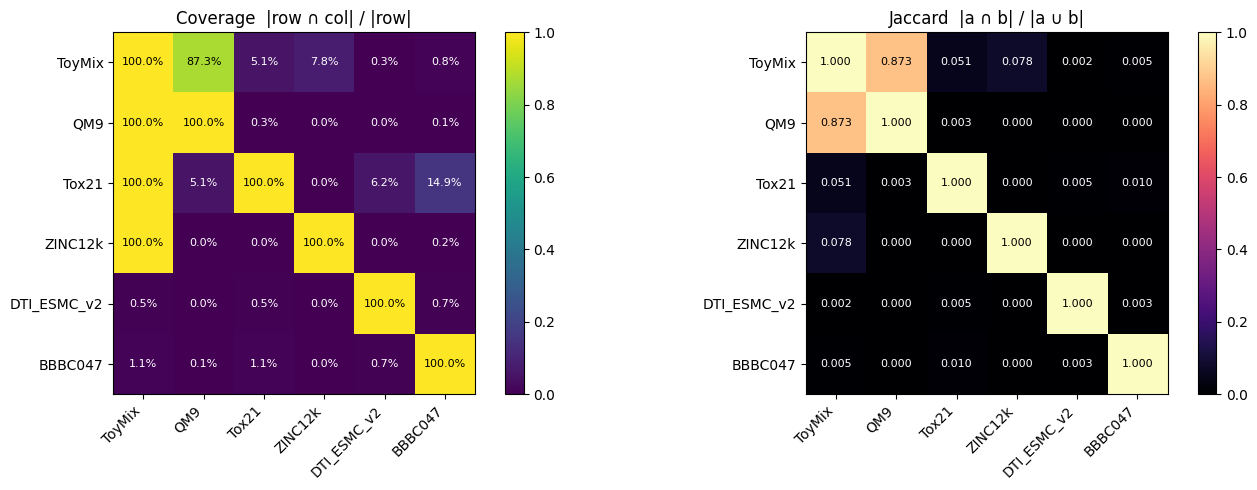

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(coverage.values.astype(float), cmap='viridis', vmin=0, vmax=1)
axes[0].set_title('Coverage  |row ∩ col| / |row|')
axes[0].set_xticks(range(len(ORDER))); axes[0].set_xticklabels(ORDER, rotation=45, ha='right')
axes[0].set_yticks(range(len(ORDER))); axes[0].set_yticklabels(ORDER)
for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        v = coverage.values[i, j]
        axes[0].text(j, i, f'{v*100:.1f}%', ha='center', va='center',
                     color='white' if v < 0.5 else 'black', fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(jaccard.values.astype(float), cmap='magma', vmin=0, vmax=1)
axes[1].set_title('Jaccard  |a ∩ b| / |a ∪ b|')
axes[1].set_xticks(range(len(ORDER))); axes[1].set_xticklabels(ORDER, rotation=45, ha='right')
axes[1].set_yticks(range(len(ORDER))); axes[1].set_yticklabels(ORDER)
for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        v = jaccard.values[i, j]
        axes[1].text(j, i, f'{v:.3f}', ha='center', va='center',
                     color='white' if v < 0.5 else 'black', fontsize=8)
fig.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 6. ToyMix ↔ DTI ↔ BBBC047 — three-way Venn

In [21]:
try:
    from matplotlib_venn import venn3
    fig, ax = plt.subplots(figsize=(7, 6))
    venn3(
        [canon_sets['ToyMix'], canon_sets['DTI_ESMC_v2'], canon_sets['BBBC047']],
        set_labels=('ToyMix', 'DTI ESMC v2', 'BBBC047'),
        ax=ax,
    )
    ax.set_title('Canonical-SMILES overlap')
    plt.show()
except ImportError:
    a, b, c = canon_sets['ToyMix'], canon_sets['DTI_ESMC_v2'], canon_sets['BBBC047']
    print('matplotlib_venn not installed - printing region counts instead')
    print(f'  ToyMix only          : {len(a - b - c):>7}')
    print(f'  DTI only             : {len(b - a - c):>7}')
    print(f'  BBBC047 only         : {len(c - a - b):>7}')
    print(f'  ToyMix ∩ DTI         : {len((a & b) - c):>7}')
    print(f'  ToyMix ∩ BBBC047     : {len((a & c) - b):>7}')
    print(f'  DTI ∩ BBBC047        : {len((b & c) - a):>7}')
    print(f'  All three            : {len(a & b & c):>7}')

matplotlib_venn not installed - printing region counts instead
  ToyMix only          :  151675
  DTI only             :   96432
  BBBC047 only         :  107884
  ToyMix ∩ DTI         :     321
  ToyMix ∩ BBBC047     :    1048
  DTI ∩ BBBC047        :     531
  All three            :     182


## 7. Quick read

In [22]:
def pct(a, b):
    return f'{100 * len(a & b) / len(a):.2f}%' if len(a) else 'n/a'

tm, dti, bbbc = canon_sets['ToyMix'], canon_sets['DTI_ESMC_v2'], canon_sets['BBBC047']
print(f'ToyMix       : {len(tm):>7}')
print(f'DTI ESMC v2  : {len(dti):>7}')
print(f'BBBC047      : {len(bbbc):>7}')
print()
print(f'  ToyMix subset of DTI       : {pct(tm,  dti)}    (DTI subset of ToyMix: {pct(dti,  tm)})')
print(f'  ToyMix subset of BBBC047   : {pct(tm,  bbbc)}    (BBBC047 subset of ToyMix: {pct(bbbc, tm)})')
print(f'  DTI subset of BBBC047      : {pct(dti, bbbc)}    (BBBC047 subset of DTI:   {pct(bbbc, dti)})')
print()
print(f'  Triple intersection : {len(tm & dti & bbbc)}')
print(f'  Union of all three  : {len(tm | dti | bbbc)}')

ToyMix       :  153226
DTI ESMC v2  :   97466
BBBC047      :  109645

  ToyMix subset of DTI       : 0.33%    (DTI subset of ToyMix: 0.52%)
  ToyMix subset of BBBC047   : 0.80%    (BBBC047 subset of ToyMix: 1.12%)
  DTI subset of BBBC047      : 0.73%    (BBBC047 subset of DTI:   0.65%)

  Triple intersection : 182
  Union of all three  : 358073


## 8. Sensitivity check: alternative SMILES identity definitions

Plain canonical SMILES treat enantiomers, salts, tautomers, and protonation states as **distinct molecules**, so the overlap counts above are a *lower bound* on chemical-identity overlap. Below we recompute the three-way overlap under two stricter definitions:

| Variant | What it ignores |
|---|---|
| **canonical SMILES** (baseline) | atom order, kekulé/aromatic, implicit Hs |
| **InChIKey, full** | + tautomers, charge state |
| **InChIKey, connectivity block** | + stereochemistry, isotopes |
| **MolStandardize → canonical** | salts/counter-ions stripped, largest fragment, neutralized |


In [23]:
from rdkit.Chem import inchi
try:
    from rdkit.Chem.MolStandardize.rdMolStandardize import (
        ChargeParent, FragmentParent, Uncharger, LargestFragmentChooser,
    )
    _HAS_STD = True
except ImportError:
    _HAS_STD = False
    print('MolStandardize not available - skipping that variant')

_lfc = LargestFragmentChooser() if _HAS_STD else None
_unc = Uncharger() if _HAS_STD else None

def canon_inchikey_full(s):
    mol = Chem.MolFromSmiles(s)
    if mol is None: return None
    try:
        return inchi.MolToInchiKey(mol) or None
    except Exception:
        return None

def canon_inchikey_block1(s):
    k = canon_inchikey_full(s)
    return k.split('-')[0] if k else None

def canon_standardized(s):
    mol = Chem.MolFromSmiles(s)
    if mol is None: return None
    try:
        mol = _lfc.choose(mol)         # strip salts / pick largest fragment
        mol = _unc.uncharge(mol)       # neutralize
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return None

def build_set(name, fn, raw):
    cache = CACHE_DIR / f'{name}__{fn.__name__}.pkl'
    if cache.exists():
        with open(cache, 'rb') as f:
            return pickle.load(f)
    out = set()
    for s in tqdm(raw, desc=f'{name} {fn.__name__}', leave=False):
        if not isinstance(s, str): continue
        k = fn(s)
        if k: out.add(k)
    with open(cache, 'wb') as f:
        pickle.dump(out, f)
    return out

# Reload raw SMILES (cached canonical sets discard them)
raw = {}
for name, (path, col) in DATASETS.items():
    raw[name] = pd.read_csv(path, usecols=[col])[col].dropna().tolist()
raw_toymix = raw['QM9'] + raw['Tox21'] + raw['ZINC12k']


In [24]:
variants = {
    'canon_smiles':   None,                 # already in canon_sets
    'inchikey_full':  canon_inchikey_full,
    'inchikey_block': canon_inchikey_block1,
}
if _HAS_STD:
    variants['standardized_canon'] = canon_standardized

three_way = {}
for vname, fn in variants.items():
    if fn is None:
        tm   = canon_sets['ToyMix']
        dti  = canon_sets['DTI_ESMC_v2']
        bbbc = canon_sets['BBBC047']
    else:
        tm   = build_set(f'ToyMix__{vname}',     fn, raw_toymix)
        dti  = build_set(f'DTI_ESMC_v2__{vname}', fn, raw['DTI_ESMC_v2'])
        bbbc = build_set(f'BBBC047__{vname}',     fn, raw['BBBC047'])
    three_way[vname] = {
        '|ToyMix|':            len(tm),
        '|DTI|':               len(dti),
        '|BBBC047|':           len(bbbc),
        'ToyMix ∩ DTI':        len(tm & dti),
        'ToyMix ∩ BBBC047':    len(tm & bbbc),
        'DTI ∩ BBBC047':       len(dti & bbbc),
        'all three':           len(tm & dti & bbbc),
    }

pd.DataFrame(three_way)


,canon_smiles,inchikey_full,inchikey_block,standardized_canon
|ToyMix|,153226,148857,148643,153007
|DTI|,97466,97431,96245,97441
|BBBC047|,109645,109645,109640,109645
ToyMix ∩ DTI,503,531,674,553
ToyMix ∩ BBBC047,1230,1420,2087,1326
DTI ∩ BBBC047,713,977,1365,729
all three,182,229,404,198


## 9. LPM-24 coverage

LPM-24 (PubMed-text → molecule, Pampuch et al.) is the fourth pre-training source. Source CSV:
`data/dti-processed/lpm24_pubmedbert.csv` (160,561 rows, `SMILES_nometa`). The PubMedBERT and Galactica
variants share the same SMILES set — only the text-encoder embedding differs — so we only load one.


In [25]:
LPM24_PATH = Path('/home/shpark/prj-molrepr/graphium/data/dti-processed/lpm24_pubmedbert.csv')
LPM24_COL  = 'SMILES_nometa'

raw['LPM24'] = pd.read_csv(LPM24_PATH, usecols=[LPM24_COL])[LPM24_COL].dropna().tolist()
print(f'LPM-24 raw rows: {len(raw["LPM24"]):,}')

# Canonical SMILES for LPM-24 (cached separately)
canon_sets['LPM24'] = load_canonical('LPM24', LPM24_PATH, LPM24_COL)
print(f'LPM-24 unique canonical SMILES: {len(canon_sets["LPM24"]):,}')


LPM-24 raw rows: 160,560
LPM-24 unique canonical SMILES: 160,560


### 9.1 Pairwise overlap counts (canon SMILES)

In [26]:
ORDER4 = ['ToyMix', 'QM9', 'Tox21', 'ZINC12k', 'DTI_ESMC_v2', 'BBBC047', 'LPM24']
inter4 = pd.DataFrame(index=ORDER4, columns=ORDER4, dtype=int)
for a in ORDER4:
    for b in ORDER4:
        inter4.loc[a, b] = len(canon_sets[a] & canon_sets[b])
inter4


,ToyMix,QM9,Tox21,ZINC12k,DTI_ESMC_v2,BBBC047,LPM24
ToyMix,153226.0,133798.0,7831.0,12000.0,503.0,1230.0,1679.0
QM9,133798.0,133798.0,402.0,0.0,32.0,98.0,343.0
Tox21,7831.0,402.0,7831.0,1.0,483.0,1167.0,1516.0
ZINC12k,12000.0,0.0,1.0,12000.0,4.0,20.0,0.0
DTI_ESMC_v2,503.0,32.0,483.0,4.0,97466.0,713.0,225.0
BBBC047,1230.0,98.0,1167.0,20.0,713.0,109645.0,618.0
LPM24,1679.0,343.0,1516.0,0.0,225.0,618.0,160560.0


### 9.2 Coverage and Jaccard with LPM-24

In [27]:
coverage4 = pd.DataFrame(index=ORDER4, columns=ORDER4, dtype=float)
jaccard4  = pd.DataFrame(index=ORDER4, columns=ORDER4, dtype=float)
for a in ORDER4:
    na = len(canon_sets[a])
    for b in ORDER4:
        inter_ab = len(canon_sets[a] & canon_sets[b])
        union_ab = len(canon_sets[a] | canon_sets[b])
        coverage4.loc[a, b] = inter_ab / na if na else np.nan
        jaccard4.loc[a, b]  = inter_ab / union_ab if union_ab else np.nan

print('Coverage  |row ∩ col| / |row|')
print((coverage4 * 100).round(2).astype(str) + '%')
print()
print('Jaccard')
print(jaccard4.round(4))


Coverage  |row ∩ col| / |row|
             ToyMix     QM9   Tox21 ZINC12k DTI_ESMC_v2 BBBC047   LPM24
ToyMix       100.0%  87.32%   5.11%   7.83%       0.33%    0.8%    1.1%
QM9          100.0%  100.0%    0.3%    0.0%       0.02%   0.07%   0.26%
Tox21        100.0%   5.13%  100.0%   0.01%       6.17%   14.9%  19.36%
ZINC12k      100.0%    0.0%   0.01%  100.0%       0.03%   0.17%    0.0%
DTI_ESMC_v2   0.52%   0.03%    0.5%    0.0%      100.0%   0.73%   0.23%
BBBC047       1.12%   0.09%   1.06%   0.02%       0.65%  100.0%   0.56%
LPM24         1.05%   0.21%   0.94%    0.0%       0.14%   0.38%  100.0%

Jaccard
             ToyMix     QM9   Tox21  ZINC12k  DTI_ESMC_v2  BBBC047   LPM24
ToyMix       1.0000  0.8732  0.0511   0.0783       0.0020   0.0047  0.0054
QM9          0.8732  1.0000  0.0028   0.0000       0.0001   0.0004  0.0012
Tox21        0.0511  0.0028  1.0000   0.0001       0.0046   0.0100  0.0091
ZINC12k      0.0783  0.0000  0.0001   1.0000       0.0000   0.0002  0.0000
DTI_ESMC_v

### 9.3 LPM-24 under stricter SMILES identity

In [28]:
# Reuse build_set / variants / fn machinery from §8
lpm24_variants = {
    'canon_smiles': canon_sets['LPM24'],
}
for vname, fn in [('inchikey_full', canon_inchikey_full),
                  ('inchikey_block', canon_inchikey_block1)]:
    lpm24_variants[vname] = build_set(f'LPM24__{vname}', fn, raw['LPM24'])
if _HAS_STD:
    lpm24_variants['standardized_canon'] = build_set('LPM24__standardized_canon', canon_standardized, raw['LPM24'])

rows = {}
for vname, lpm in lpm24_variants.items():
    if vname == 'canon_smiles':
        tm   = canon_sets['ToyMix']
        dti  = canon_sets['DTI_ESMC_v2']
        bbbc = canon_sets['BBBC047']
    else:
        tm   = build_set(f'ToyMix__{vname}',      None if vname == 'canon_smiles' else
                        {'inchikey_full': canon_inchikey_full,
                         'inchikey_block': canon_inchikey_block1,
                         'standardized_canon': canon_standardized}[vname], raw_toymix)
        dti  = build_set(f'DTI_ESMC_v2__{vname}',
                        {'inchikey_full': canon_inchikey_full,
                         'inchikey_block': canon_inchikey_block1,
                         'standardized_canon': canon_standardized}[vname], raw['DTI_ESMC_v2'])
        bbbc = build_set(f'BBBC047__{vname}',
                        {'inchikey_full': canon_inchikey_full,
                         'inchikey_block': canon_inchikey_block1,
                         'standardized_canon': canon_standardized}[vname], raw['BBBC047'])
    rows[vname] = {
        '|LPM24|':            len(lpm),
        'LPM24 ∩ ToyMix':     len(lpm & tm),
        'LPM24 ∩ DTI':        len(lpm & dti),
        'LPM24 ∩ BBBC047':    len(lpm & bbbc),
        'LPM24 ∩ all-three':  len(lpm & tm & dti & bbbc),
        '∪ all four':         len(lpm | tm | dti | bbbc),
    }
pd.DataFrame(rows)


,canon_smiles,inchikey_full,inchikey_block,standardized_canon
|LPM24|,160560,160555,147187,160175
LPM24 ∩ ToyMix,1679,1726,2032,1858
LPM24 ∩ DTI,225,239,479,272
LPM24 ∩ BBBC047,618,671,792,701
LPM24 ∩ all-three,50,66,129,65
∪ all four,516531,511625,495453,515547


## 10. Multi-set overlap stats: ToyMix / DTI / BBBC047 / LPM-24

All pairwise, triple, and quadruple intersections — using **canonical SMILES** as the identity.
The four sets are essentially disjoint: 99.4% of the union belongs to exactly one source.


In [29]:
from itertools import combinations
from collections import Counter

NAMES = ['ToyMix', 'DTI_ESMC_v2', 'BBBC047', 'LPM24']
sets4 = {n: canon_sets[n] for n in NAMES}

print('Set sizes (canonical SMILES):')
for n in NAMES:
    print(f'  {n:13} : {len(sets4[n]):>7,}')
union_all = set().union(*sets4.values())
print(f'  {"UNION":13} : {len(union_all):>7,}')
print()

print('PAIRS  (a ∩ b):')
pair_rows = []
for a, b in combinations(NAMES, 2):
    inter = sets4[a] & sets4[b]
    union = sets4[a] | sets4[b]
    smaller = min(len(sets4[a]), len(sets4[b]))
    pair_rows.append({
        'A': a, 'B': b,
        '|A∩B|': len(inter),
        'jaccard': round(len(inter) / union, 4),
        'pct_of_smaller': f'{100*len(inter)/smaller:.2f}%',
    })
print(pd.DataFrame(pair_rows).to_string(index=False))
print()

print('TRIPLES  (a ∩ b ∩ c):')
trip_rows = []
for trio in combinations(NAMES, 3):
    inter = sets4[trio[0]] & sets4[trio[1]] & sets4[trio[2]]
    trip_rows.append({'sets': ' ∩ '.join(trio), 'count': len(inter)})
print(pd.DataFrame(trip_rows).to_string(index=False))
print()

inter4 = sets4['ToyMix'] & sets4['DTI_ESMC_v2'] & sets4['BBBC047'] & sets4['LPM24']
print(f'QUADRUPLE  ToyMix ∩ DTI ∩ BBBC047 ∩ LPM24 : {len(inter4):,}')


Set sizes (canonical SMILES):
  ToyMix        : 153,226
  DTI_ESMC_v2   :  97,466
  BBBC047       : 109,645
  LPM24         : 160,560
  UNION         : 516,531

PAIRS  (a ∩ b):


TypeError: unsupported operand type(s) for /: 'int' and 'set'

### 10.1 Disjoint Venn regions

For each subset of the four sources, count how many SMILES belong to **exactly** that combination
(each SMILES counted once). These rows sum to the union (516,531).

In [ ]:
# Membership pattern → count (each SMILES classified once by which sources it appears in)
membership_pattern = Counter()
for s in union_all:
    pat = tuple(n for n in NAMES if s in sets4[n])
    membership_pattern[pat] += 1

region_rows = []
for pat in sorted(membership_pattern.keys(), key=lambda p: (len(p), p)):
    region_rows.append({
        'arity': len(pat),
        'region': ' & '.join(pat) if pat else '∅',
        'count': membership_pattern[pat],
        'pct_of_union': f'{100*membership_pattern[pat]/len(union_all):.2f}%',
    })
regions_df = pd.DataFrame(region_rows)
print(regions_df.to_string(index=False))
print()
print(f'Sanity: regions sum to {sum(membership_pattern.values()):,}  '
      f'vs union {len(union_all):,}')


### 10.2 Multi-set bar chart

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
labels = [r['region'] for r in region_rows]
counts = [r['count']  for r in region_rows]
arity  = [r['arity']  for r in region_rows]
colors = {1: '#4C72B0', 2: '#DD8452', 3: '#55A868', 4: '#C44E52'}
bar_colors = [colors[a] for a in arity]

bars = ax.bar(range(len(labels)), counts, color=bar_colors)
ax.set_yscale('log')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('SMILES count (log)')
ax.set_title('Disjoint Venn regions across ToyMix / DTI / BBBC047 / LPM-24')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{c:,}',
            ha='center', va='bottom', fontsize=7)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=colors[k], label=f'{k}-way') for k in (1, 2, 3, 4)],
          loc='upper right')
plt.tight_layout()
plt.show()
